In [24]:
import numpy as np
import pandas as pd
from scipy.spatial.transform import Rotation as R


def normalize_vector(v, eps=1e-12):
    """
    Normaliza un vector 3D.
    """
    n = np.linalg.norm(v)
    if n < eps:
        raise ValueError("Vector con norma casi cero, no se puede normalizar.")
    return v / n


def rotation_from_two_vectors(a, b):
    """
    Retorna una matriz R tal que aproximadamente:

        R @ a = b

    donde a y b son vectores 3D unitarios.

    Usa la fórmula de Rodrigues.
    """
    a = normalize_vector(np.asarray(a, dtype=float))
    b = normalize_vector(np.asarray(b, dtype=float))

    v = np.cross(a, b)
    c = np.dot(a, b)
    s = np.linalg.norm(v)

    # Caso: vectores casi iguales
    if s < 1e-12 and c > 0:
        return np.eye(3)

    # Caso: vectores opuestos
    if s < 1e-12 and c < 0:
        # Elegir un eje perpendicular arbitrario
        axis = np.array([1.0, 0.0, 0.0])
        if abs(a[0]) > 0.9:
            axis = np.array([0.0, 1.0, 0.0])

        axis = normalize_vector(np.cross(a, axis))
        return R.from_rotvec(np.pi * axis).as_matrix()

    vx = np.array([
        [0,      -v[2],   v[1]],
        [v[2],    0,    -v[0]],
        [-v[1],  v[0],   0]
    ])

    R_mat = np.eye(3) + vx + vx @ vx * ((1 - c) / (s ** 2))

    return R_mat


def calibrate_static_roll_pitch(
    df,
    acc_cols=("ax", "ay", "az"),
    gyro_cols=None,
    time_col="t",
    t_start=None,
    t_end=None,
    zupt_flag_col=None,
    expected_specific_force_vehicle=np.array([0.0, 0.0, -1.0]),
    gyro_threshold=None,
    verbose=True
):
    """
    Calibración estática de roll/pitch IMU -> vehículo usando fuerza específica.

    Parámetros
    ----------
    df:
        DataFrame con aceleraciones del IMU.
    
    acc_cols:
        Columnas de acelerómetro que contienen fuerza específica.
        Ejemplo:
            ("scaledAccelX", "scaledAccelY", "scaledAccelZ")
        o:
            ("ax", "ay", "az")

    gyro_cols:
        Opcional. Columnas de giroscopio para validar reposo.
        Ejemplo:
            ("gx", "gy", "gz")

    time_col:
        Columna de tiempo en segundos.

    t_start, t_end:
        Ventana estática manual.

    zupt_flag_col:
        Opcional. Si existe, usa filas donde zupt_flag == 1.

    expected_specific_force_vehicle:
        Vector esperado de fuerza específica en marco vehículo.
        Para vehículo con Z positivo hacia abajo:
            [0, 0, -1]
        Para vehículo con Z positivo hacia arriba:
            [0, 0, +1]

    gyro_threshold:
        Opcional. Umbral de norma giroscópica para filtrar muestras quietas.

    Retorna
    -------
    result:
        Diccionario con:
        - R_vb_rp: matriz de rotación IMU -> vehículo, solo roll/pitch
        - q_vb_rp_xyzw: cuaternión scipy [x, y, z, w]
        - f_b_mean: promedio medido en IMU
        - f_b_unit: dirección medida normalizada
        - f_v_expected_unit: dirección esperada normalizada
        - f_v_after: fuerza específica promedio rotada al vehículo
        - roll_pitch_calib_euler_deg: euler aproximado de la corrección
    """

    work = df.copy()

    # 1. Filtrar por ventana de tiempo
    mask = np.ones(len(work), dtype=bool)

    if t_start is not None:
        mask &= work[time_col].to_numpy() >= t_start

    if t_end is not None:
        mask &= work[time_col].to_numpy() <= t_end

    # 2. Filtrar por ZUPT flag
    if zupt_flag_col is not None and zupt_flag_col in work.columns:
        mask &= work[zupt_flag_col].to_numpy().astype(bool)

    # 3. Filtrar por giroscopio bajo
    if gyro_cols is not None and gyro_threshold is not None:
        gyro = work[list(gyro_cols)].to_numpy(dtype=float)
        gyro_norm = np.linalg.norm(gyro, axis=1)
        mask &= gyro_norm < gyro_threshold

    static_df = work.loc[mask].copy()

    if len(static_df) < 10:
        raise ValueError("Muy pocas muestras estáticas para calibrar.")

    # 4. Promedio de fuerza específica en IMU
    f_b_samples = static_df[list(acc_cols)].to_numpy(dtype=float)
    f_b_mean = np.mean(f_b_samples, axis=0)
    f_b_unit = normalize_vector(f_b_mean)

    # 5. Vector esperado en vehículo
    f_v_expected_unit = normalize_vector(expected_specific_force_vehicle)

    # 6. Rotación IMU -> vehículo que alinea f_b con f_v_expected
    R_vb_rp = rotation_from_two_vectors(f_b_unit, f_v_expected_unit)

    # 7. Validación: cómo queda el promedio después de rotar
    f_v_after = R_vb_rp @ f_b_mean

    # 8. Cuaternión equivalente
    q_vb_rp_xyzw = R.from_matrix(R_vb_rp).as_quat()

    # 9. Euler aproximado de la corrección
    euler_deg = R.from_matrix(R_vb_rp).as_euler("xyz", degrees=True)

    result = {
        "R_vb_rp": R_vb_rp,
        "q_vb_rp_xyzw": q_vb_rp_xyzw,
        "f_b_mean": f_b_mean,
        "f_b_unit": f_b_unit,
        "f_v_expected_unit": f_v_expected_unit,
        "f_v_after": f_v_after,
        "roll_pitch_calib_euler_deg_xyz": euler_deg,
        "num_static_samples": len(static_df),
        "static_df": static_df,
    }

    if verbose:
        print("R_vb_rp: ", R_vb_rp)
        print("Muestras usadas:", len(static_df))
        print("f_b_mean IMU:", f_b_mean)
        print("||f_b_mean||:", np.linalg.norm(f_b_mean))
        print("f_b_unit IMU:", f_b_unit)
        print("f_v_expected_unit:", f_v_expected_unit)
        print("f_v_after:", f_v_after)
        print("Euler corrección xyz [deg]:", euler_deg)
        print("q_vb_rp scipy [x, y, z, w]:", q_vb_rp_xyzw)

    return result

In [ ]:
import numpy as np
import pandas as pd
from scipy.spatial.transform import Rotation as R


def read_scaled_accel_file(filepath):
    """
    Lee un CSV de SensorConnect con columnas:
        Time,
        inertial-XXXX:scaledAccelX,
        inertial-XXXX:scaledAccelY,
        inertial-XXXX:scaledAccelZ

    También soporta archivos que tienen una línea DATA_START antes del header.
    """

    # Buscar si existe DATA_START
    with open(filepath, "r", encoding="utf-8") as f:
        lines = f.readlines()

    data_start_idx = None
    for i, line in enumerate(lines):
        if line.strip() == "DATA_START":
            data_start_idx = i
            break

    if data_start_idx is not None:
        df = pd.read_csv(filepath, skiprows=data_start_idx + 1)
    else:
        df = pd.read_csv(filepath)

    # Limpiar nombres de columnas
    df.columns = df.columns.str.strip()

    # Encontrar columnas por sufijo, sin depender del prefijo inertial-XXXX
    time_col = "Time"

    ax_col = [c for c in df.columns if c.endswith("scaledAccelX")][0]
    ay_col = [c for c in df.columns if c.endswith("scaledAccelY")][0]
    az_col = [c for c in df.columns if c.endswith("scaledAccelZ")][0]

    # Renombrar a nombres simples
    df = df.rename(columns={
        time_col: "Time",
        ax_col: "ax",
        ay_col: "ay",
        az_col: "az",
    })

    # Convertir a numérico
    df["Time"] = pd.to_numeric(df["Time"], errors="coerce")
    df["ax"] = pd.to_numeric(df["ax"], errors="coerce")
    df["ay"] = pd.to_numeric(df["ay"], errors="coerce")
    df["az"] = pd.to_numeric(df["az"], errors="coerce")

    df = df.dropna(subset=["Time", "ax", "ay", "az"]).copy()

    # Crear tiempo relativo en segundos
    # Tu Time está en nanosegundos Unix
    df["t"] = (df["Time"] - df["Time"].iloc[0]) / 1e9

    return df

In [26]:
filepath = r"calibracion_orientacion\acel_3.csv"

df = read_scaled_accel_file(filepath)

print(df.head())
print(df[["ax", "ay", "az"]].mean())
print(np.linalg.norm(df[["ax", "ay", "az"]].mean()))

                  Time        ax        ay        az  \
0  1778863404420288256  0.337870 -0.024410 -0.938719   
1  1778863404430288640  0.338007 -0.024189 -0.938831   
2  1778863404440460544  0.337796 -0.024197 -0.938559   
3  1778863404450612224  0.337929 -0.024272 -0.938568   
4  1778863404460743936  0.338086 -0.024305 -0.938147   

   inertial-6286.188876:scaledGyroX  inertial-6286.188876:scaledGyroY  \
0                         -0.000014                          0.000009   
1                         -0.000015                          0.000203   
2                          0.000002                          0.000439   
3                         -0.000199                         -0.000141   
4                         -0.000249                         -0.000184   

   inertial-6286.188876:scaledGyroZ         t  
0                         -0.000080  0.000000  
1                         -0.000187  0.010000  
2                         -0.000040  0.020172  
3                          0.000

In [27]:
calib = calibrate_static_roll_pitch(
    df,
    acc_cols=("ax", "ay", "az"),
    time_col="t",
    t_start=None,
    t_end=5,
    expected_specific_force_vehicle=np.array([0.0, 0.0, -1.0]),
    verbose=True
)

R_vb_rp = calib["R_vb_rp"]
q_vb_rp = calib["q_vb_rp_xyzw"]

R_vb_rp:  [[ 0.94088997  0.00425861  0.33868558]
 [ 0.00425861  0.99969319 -0.02440075]
 [-0.33868558  0.02440075  0.94058316]]
Muestras usadas: 500
f_b_mean IMU: [ 0.3378879  -0.02434328 -0.93836788]
||f_b_mean||: 0.9976447801788563
f_b_unit IMU: [ 0.33868558 -0.02440075 -0.94058316]
f_v_expected_unit: [ 0.  0. -1.]
f_v_after: [-4.74752215e-17 -2.57724620e-18 -9.97644780e-01]
Euler corrección xyz [deg]: [ 1.48604216 19.79681285  0.25932738]
q_vb_rp scipy [x, y, z, w]: [0.01238574 0.17191572 0.         0.9850338 ]


In [28]:
# calibracion dinamica

In [29]:
import numpy as np
import pandas as pd
from scipy.spatial.transform import Rotation as R


def integrate_trapezoidal(a, t):
    """
    Integra aceleración a velocidad y posición usando regla trapezoidal.

    a: array Nx3, aceleración en m/s^2
    t: array N, tiempo en segundos
    """
    N = len(t)

    v = np.zeros((N, 3))
    p = np.zeros((N, 3))

    for k in range(1, N):
        dt = t[k] - t[k - 1]

        if not np.isfinite(dt) or dt <= 0:
            dt = 0.0

        v[k] = v[k - 1] + 0.5 * (a[k] + a[k - 1]) * dt
        p[k] = p[k - 1] + 0.5 * (v[k] + v[k - 1]) * dt

    return v, p


def remove_linear_velocity_drift(v, t, t_static_ini=None, t_static_end=None):
    """
    Corrección simple de drift de velocidad.
    Fuerza que la velocidad inicial y final sean cercanas a cero.

    Útil si la prueba tiene reposo al inicio y al final.
    """
    v_corr = v.copy()
    N = len(t)

    if N < 2:
        return v_corr

    # Drift lineal entre v[0] y v[-1]
    alpha = ((t - t[0]) / (t[-1] - t[0])).reshape(-1, 1)
    drift = (1 - alpha) * v[0] + alpha * v[-1]

    v_corr = v - drift

    return v_corr


def prepare_acc_for_yaw_calibration(
    df,
    R_vb_rp,
    acc_cols=("ax", "ay", "az"),
    acc_type="scaled_g",
    g=9.80665
):
    """
    Prepara aceleración para calibración dinámica yaw.

    acc_type:
        "linear_ms2":
            La aceleración ya es lineal en m/s^2, sin gravedad.
            Ejemplo: estLinearAccel en m/s^2.

        "scaled_g":
            La señal es fuerza específica en unidades g.
            Ejemplo: scaledAccelX/Y/Z con reposo ≈ [0,0,-1].

        "scaled_ms2":
            La señal es fuerza específica en m/s^2.
            Ejemplo: scaledAccelX/Y/Z con reposo ≈ [0,0,-9.81].
    """

    acc_b = df[list(acc_cols)].to_numpy(dtype=float)

    # 1. Aplicar calibración roll/pitch IMU -> vehículo nivelado
    acc_rp = (R_vb_rp @ acc_b.T).T

    # 2. Compensar gravedad según el tipo de señal
    if acc_type == "linear_ms2":
        # Ya viene sin gravedad
        a_rp_ms2 = acc_rp

    elif acc_type == "scaled_g":
        # En tu caso estático queda aprox [0,0,-1]
        # Por tanto, aceleración lineal en g:
        a_rp_g = acc_rp - np.array([0.0, 0.0, -1.0])
        a_rp_ms2 = a_rp_g * g

    elif acc_type == "scaled_ms2":
        # En reposo debería quedar aprox [0,0,-9.80665]
        a_rp_ms2 = acc_rp - np.array([0.0, 0.0, -g])

    else:
        raise ValueError("acc_type debe ser 'linear_ms2', 'scaled_g' o 'scaled_ms2'")

    return a_rp_ms2


def calibrate_yaw_dynamic_sweep(
    df,
    R_vb_rp,
    acc_cols=("ax", "ay", "az"),
    time_col="t",
    t_start=None,
    t_end=None,
    acc_type="scaled_g",
    yaw_min_deg=-180,
    yaw_max_deg=180,
    yaw_step_deg=0.5,
    use_velocity_drift_correction=True,
    cost_mode="combined",
    verbose=True
):
    """
    Calibra yaw de montaje IMU -> vehículo usando una prueba recta.

    Retorna:
        best:
            diccionario con mejor yaw, costo, distancia, etc.

        results_df:
            tabla con resultados de todos los yaw probados.

        R_vb:
            rotación total IMU -> vehículo = R_yaw @ R_vb_rp
    """

    work = df.copy()

    # Filtrar ventana dinámica
    mask = np.ones(len(work), dtype=bool)

    if t_start is not None:
        mask &= work[time_col].to_numpy() >= t_start

    if t_end is not None:
        mask &= work[time_col].to_numpy() <= t_end

    work = work.loc[mask].copy()

    if len(work) < 20:
        raise ValueError("Muy pocas muestras para calibración dinámica yaw.")

    t = work[time_col].to_numpy(dtype=float)

    # Llevar t a cero para estabilidad numérica
    t = t - t[0]

    # Aceleración nivelada y compensada de gravedad
    a_rp_ms2 = prepare_acc_for_yaw_calibration(
        work,
        R_vb_rp=R_vb_rp,
        acc_cols=acc_cols,
        acc_type=acc_type
    )

    yaw_values = np.arange(yaw_min_deg, yaw_max_deg + yaw_step_deg, yaw_step_deg)

    rows = []

    best = None

    for yaw_deg in yaw_values:
        R_yaw = R.from_euler("z", yaw_deg, degrees=True).as_matrix()

        # Rotación total IMU -> vehículo para este yaw
        R_vb_candidate = R_yaw @ R_vb_rp

        # Como a_rp_ms2 ya está nivelada por R_vb_rp,
        # aquí solo aplicamos yaw a esa aceleración
        a_vehicle = (R_yaw @ a_rp_ms2.T).T

        # Integrar
        v_vehicle, p_vehicle = integrate_trapezoidal(a_vehicle, t)

        # Corrección simple de drift de velocidad si hay reposo inicial/final
        if use_velocity_drift_correction:
            v_vehicle = remove_linear_velocity_drift(v_vehicle, t)
            p_vehicle = np.zeros_like(p_vehicle)

            for k in range(1, len(t)):
                dt = t[k] - t[k - 1]
                p_vehicle[k] = p_vehicle[k - 1] + 0.5 * (v_vehicle[k] + v_vehicle[k - 1]) * dt

        vx = v_vehicle[:, 0]
        vy = v_vehicle[:, 1]

        px = p_vehicle[:, 0]
        py = p_vehicle[:, 1]

        # Métricas
        mean_vy2 = np.mean(vy**2)
        mean_py2 = np.mean(py**2)

        final_px = px[-1] - px[0]
        final_py = py[-1] - py[0]

        rms_py = np.sqrt(np.mean(py**2))
        rms_vy = np.sqrt(np.mean(vy**2))

        # Costo
        if cost_mode == "vy":
            cost = mean_vy2

        elif cost_mode == "py":
            cost = mean_py2

        elif cost_mode == "combined":
            # Normalización sencilla para no depender tanto de unidades
            cost = mean_vy2 + 0.05 * mean_py2

        elif cost_mode == "straightness":
            # Penaliza desplazamiento lateral relativo al avance
            cost = abs(final_py) / (abs(final_px) + 1e-9) + 0.1 * rms_py

        else:
            raise ValueError("cost_mode debe ser 'vy', 'py', 'combined' o 'straightness'")

        row = {
            "yaw_deg": yaw_deg,
            "cost": cost,
            "mean_vy2": mean_vy2,
            "mean_py2": mean_py2,
            "rms_vy": rms_vy,
            "rms_py": rms_py,
            "final_px": final_px,
            "final_py": final_py,
            "abs_final_py": abs(final_py),
            "straightness_ratio": abs(final_py) / (abs(final_px) + 1e-9),
        }

        rows.append(row)

        if best is None or cost < best["cost"]:
            best = row.copy()
            best["R_yaw"] = R_yaw
            best["R_vb"] = R_vb_candidate
            best["a_vehicle"] = a_vehicle
            best["v_vehicle"] = v_vehicle
            best["p_vehicle"] = p_vehicle

    results_df = pd.DataFrame(rows)

    if verbose:
        print("Mejor yaw dinámico [deg]:", best["yaw_deg"])
        print("Costo:", best["cost"])
        print("Distancia longitudinal final X [m]:", best["final_px"])
        print("Distancia lateral final Y [m]:", best["final_py"])
        print("Ratio lateral/longitudinal:", best["straightness_ratio"])
        print("\nR_vb total = R_yaw @ R_vb_rp:")
        print(best["R_vb"])
        print("\nEuler R_vb total xyz [deg]:")
        print(R.from_matrix(best["R_vb"]).as_euler("xyz", degrees=True))
        print("\nCuaternión R_vb total scipy [x,y,z,w]:")
        print(R.from_matrix(best["R_vb"]).as_quat())

    return best, results_df

In [30]:
best_yaw, yaw_results = calibrate_yaw_dynamic_sweep(
    df,
    R_vb_rp=R_vb_rp,
    acc_cols=("ax", "ay", "az"),
    time_col="t",
    t_start=5,
    t_end=25,
    acc_type="scaled_g",
    yaw_min_deg=-180,
    yaw_max_deg=180,
    yaw_step_deg=0.5,
    use_velocity_drift_correction=True,
    cost_mode="combined",
    verbose=True
)

yaw_mount_deg = best_yaw["yaw_deg"]
R_vb = best_yaw["R_vb"]
q_vb_xyzw = R.from_matrix(R_vb).as_quat()

Mejor yaw dinámico [deg]: 59.5
Costo: 2.4383595650465633e-08
Distancia longitudinal final X [m]: 0.0011796226441829613
Distancia lateral final Y [m]: 7.492230652875775e-05
Ratio lateral/longitudinal: 0.06351373753673015

R_vb total = R_yaw @ R_vb_rp:
[[ 0.47386842 -0.85920339  0.19292032]
 [ 0.81285964  0.51105198  0.27943706]
 [-0.33868558  0.02440075  0.94058316]]

Euler R_vb total xyz [deg]:
[ 1.48604216 19.79681285 59.75932738]

Cuaternión R_vb total scipy [x,y,z,w]:
[-0.07455413  0.15540303  0.48879003  0.85520517]


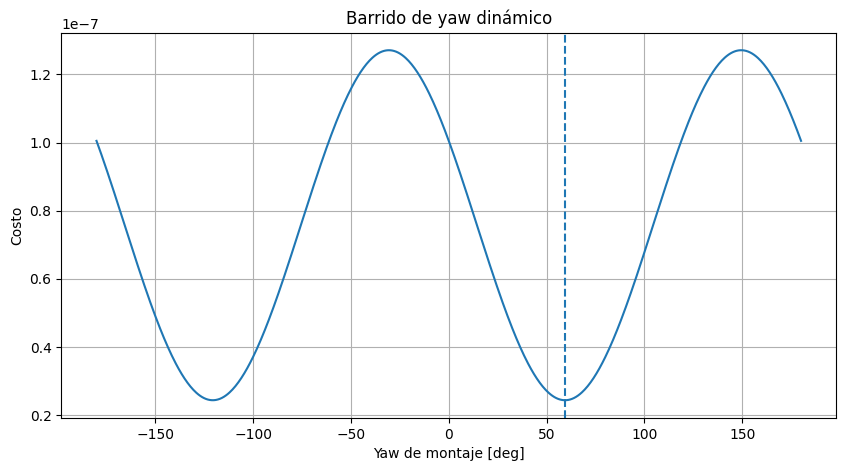

In [31]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(yaw_results["yaw_deg"], yaw_results["cost"])
plt.axvline(best_yaw["yaw_deg"], linestyle="--")
plt.xlabel("Yaw de montaje [deg]")
plt.ylabel("Costo")
plt.title("Barrido de yaw dinámico")
plt.grid(True)
plt.show()

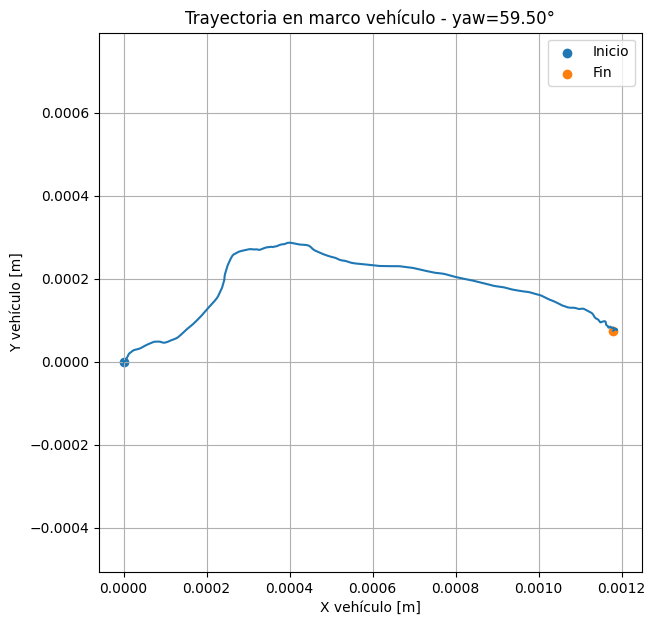

In [32]:
p_vehicle = best_yaw["p_vehicle"]

plt.figure(figsize=(7, 7))
plt.plot(p_vehicle[:, 0], p_vehicle[:, 1])
plt.scatter(p_vehicle[0, 0], p_vehicle[0, 1], label="Inicio")
plt.scatter(p_vehicle[-1, 0], p_vehicle[-1, 1], label="Fin")
plt.xlabel("X vehículo [m]")
plt.ylabel("Y vehículo [m]")
plt.title(f"Trayectoria en marco vehículo - yaw={best_yaw['yaw_deg']:.2f}°")
plt.axis("equal")
plt.grid(True)
plt.legend()
plt.show()